# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Advanced filter methods:** Build on the filters from this notebook to  emulate filters from social media or photo-editing apps!
* **Advanced image recognition techniques:** Extend the object detection problem to be more general, handle more objects, etx

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: "CartoonGAN: Generative Adversarial Networks for Photo Cartoonization" (CVPR 2018). This paper introduces a GAN that learns to turn real photos into cartoons without needing paired data. It’s based on the idea that cartoons have simple textures and strong edges, which normal losses like VGG perceptual loss don’t capture well. Because of that, it’s considered a key early paper for learned cartoonization. <https://openaccess.thecvf.com/content_cvpr_2018/papers/Chen_CartoonGAN_Generative_Adversarial_CVPR_2018_paper.pdf>
* Source 2: "Learning to Cartoonize Using White-Box Cartoon Representations" (CVPR 2020). This paper breaks cartoons into three parts, including surface (smooth shading), structure (simple color regions), and texture (edges and details), and uses each to guide different GAN losses. These parts line up closely with the classic pipeline steps, so it helps connect traditional methods with learning based ones. <https://systemerrorwang.github.io/White-box-Cartoonization/>
* Source 3: "Non-Photorealistic Rendering using OpenCV" (LearnOpenCV tutorial). Goes through OpenCV’s built-in filters like edge-preserving, detail-enhance, pencil-sketch, and stylization, and compares them to a basic Gaussian blur + edge detection pipeline. It shows why bilateral filtering works better for cartoon effects since it smooths colors while keeping edges sharp. <https://learnopencv.com/non-photorealistic-rendering-using-opencv-python-c/>
* Source 4: AnimeGANv2 (open-source GitHub repo). This is a lightweight GAN for turning photos into anime, with a small generator and training data from BD movies. It also provides pretrained models for styles like Hayao, Shinkai, and Paprika, plus easy PyTorch inference scripts. I use it as the learned baseline when comparing against the classical pipeline. <https://github.com/TachibanaYoshino/AnimeGANv2>
* Source 5: "Bilateral Filtering for Gray and Color Images" (ICCV 1998). The original paper introduces bilateral filtering, which smooths images while keeping edges sharp by combining spatial and intensity information. This method is at the core of most classical cartoonization pipelines, so citing it gives a solid primary source instead of just relying on tutorials. <https://users.soe.ucsc.edu/~manduchi/Papers/ICCV98.pdf>

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [1]:
#setup
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from pathlib import Path


plt.rcParams['figure.dpi'] = 110
plt.rcParams['image.interpolation'] = 'nearest'

In [4]:
#upload picture
from google.colab import files
import cv2
import numpy as np

image = files.upload()
filename = list(image.keys())[0]
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(img.shape)

def show(imgs, titles=None, figsize=None, cmap_gray=True):

    if not isinstance(imgs, (list, tuple)):
        imgs = [imgs]
    n = len(imgs)
    figsize = figsize or (4 * n, 4)
    fig, ax = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        ax = [ax]
    for a, im, t in zip(ax, imgs, titles or [""] * n):
        if im.ndim == 2 and cmap_gray:
            a.imshow(im, cmap="gray")
        else:
            a.imshow(im)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()

Saving test.jpg to test (1).jpg
(960, 1440, 3)


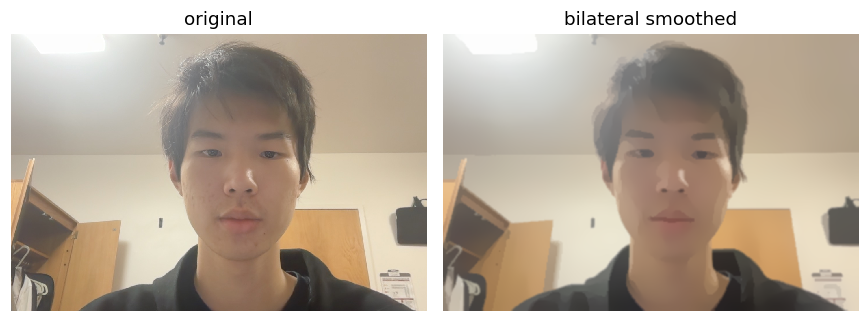

In [5]:
#pipeline for cartoonization
#smooth -> flatten -> outline

def edge_preserving_smooth(img, num_down=2, num_bilateral=7,
                           d=9, sigma_color=9, sigma_space=7):
    out = img.copy()
    for _ in range(num_down):
        out = cv2.pyrDown(out)
    for _ in range(num_bilateral):
        out = cv2.bilateralFilter(out, d=d,
                                  sigmaColor=sigma_color,
                                  sigmaSpace=sigma_space)
    for _ in range(num_down):
        out = cv2.pyrUp(out)
    return out


smoothed = edge_preserving_smooth(img, num_bilateral=7)
smoothed = cv2.resize(smoothed, (img.shape[1], img.shape[0]))
show([img, smoothed], titles=["original", "bilateral smoothed"])


In [ ]:
def color_quantize(img, k=8, attempts=3):
    data = img.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 0.5)
    _, labels, centers = cv2.kmeans(
        data, k, None, criteria, attempts, cv2.KMEANS_PP_CENTERS
    )
    centers = centers.astype(np.uint8)
    return centers[labels.flatten()].reshape(img.shape)


ks = [4, 8, 16, 32]
quantized_variants = [color_quantize(smoothed, k=k) for k in ks]
show(quantized_variants, titles=[f"k = {k}" for k in ks], figsize=(16, 4))

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_